# 1. Install + Setup

In [ ]:
!pip install torch transformers matplotlib

In [ ]:
import time, math
from dataclasses import dataclass
from typing import Dict, List

import torch
from transformers import LlamaConfig, LlamaForCausalLM
import matplotlib.pyplot as plt

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))

torch: 2.10.0+cu128
cuda available: True
gpu: Tesla T4


# 2. KV cache sizing helpers

In [ ]:
DTYPE_BYTES = {
    torch.float32: 4,
    torch.float16: 2,
    torch.bfloat16: 2,
    torch.int8: 1,
}

def sizeof_past_key_values(past_key_values) -> int:
    if past_key_values is None:
        return 0

    # If transformers returns a Cache object, convert to legacy tuple format if possible
    if hasattr(past_key_values, "to_legacy_cache"):
        past_key_values = past_key_values.to_legacy_cache()

    total = 0

    # Expected legacy format: tuple(num_layers) of tuples (k, v)
    for layer_kv in past_key_values:
        if layer_kv is None:
            continue

        # layer_kv might be (k, v) or something similar
        if isinstance(layer_kv, (tuple, list)):
            for t in layer_kv:
                if t is None:
                    continue
                total += t.numel() * t.element_size()
        else:
            # Unexpected single tensor (rare), handle anyway
            t = layer_kv
            if t is not None and hasattr(t, "numel"):
                total += t.numel() * t.element_size()

    return total

def analytical_kv_bytes(
    num_layers: int,
    batch_size: int,
    seq_len: int,
    num_kv_heads: int,
    head_dim: int,
    dtype: torch.dtype,
) -> int:
    bytes_per = DTYPE_BYTES.get(dtype, torch.tensor([], dtype=dtype).element_size())
    return 2 * num_layers * batch_size * seq_len * num_kv_heads * head_dim * bytes_per  # 2 for K+V

def bytes_to_gb(nbytes: int) -> float:
    return nbytes / (1024**3)

def gpu_mem_gb():
    if not torch.cuda.is_available():
        return None
    alloc = torch.cuda.memory_allocated() / (1024**3)
    reserv = torch.cuda.memory_reserved() / (1024**3)
    return alloc, reserv

# 3. Build model configs for MHA vs GQA

In [ ]:
@dataclass
class SimConfig:
    hidden_size: int = 1024
    num_layers: int = 16
    num_heads: int = 16
    num_kv_heads: int = 16  # MHA: = num_heads, GQA: smaller

    vocab_size: int = 32000
    max_position_embeddings: int = 16384

    batch_size: int = 1
    total_tokens: int = 4096
    prompt_tokens: int = 128
    measure_every: int = 256

    dtype: torch.dtype = torch.float16
    device: str = "cuda" if torch.cuda.is_available() else "cpu"

def build_llama_model(cfg: SimConfig) -> LlamaForCausalLM:
    assert cfg.hidden_size % cfg.num_heads == 0

    llama_cfg = LlamaConfig(
        vocab_size=cfg.vocab_size,
        hidden_size=cfg.hidden_size,
        intermediate_size=4 * cfg.hidden_size,
        num_hidden_layers=cfg.num_layers,
        num_attention_heads=cfg.num_heads,
        num_key_value_heads=cfg.num_kv_heads,
        max_position_embeddings=cfg.max_position_embeddings,
        rms_norm_eps=1e-5,
        rope_theta=10000.0,
        attention_bias=False,
        # This keeps cache format stable across transformer versions/backends
        attn_implementation="eager",
    )

    model = LlamaForCausalLM(llama_cfg).to(cfg.device).eval()
    model = model.to(dtype=cfg.dtype)
    return model

# 4. Simulation: token-by-token KV growth

In [ ]:
@torch.no_grad()
def run_kv_growth(cfg: SimConfig) -> Dict[str, List]:
    model = build_llama_model(cfg)
    head_dim = cfg.hidden_size // cfg.num_heads

    # synthetic prompt
    prompt_ids = torch.randint(
        0, cfg.vocab_size, (cfg.batch_size, cfg.prompt_tokens), device=cfg.device
    )

    # Prefill
    t0 = time.time()
    out = model(input_ids=prompt_ids, use_cache=True)
    past = out.past_key_values
    prefill_ms = (time.time() - t0) * 1000

    results = {
        "seq_len": [],
        "kv_gb_empirical": [],
        "kv_gb_analytical": [],
        "step_time_ms": [],
        "gpu_alloc_gb": [],
        "gpu_reserved_gb": [],
    }

    def record(seq_len: int, step_ms: float):
        emp = sizeof_past_key_values(past)
        ana = analytical_kv_bytes(
            num_layers=cfg.num_layers,
            batch_size=cfg.batch_size,
            seq_len=seq_len,
            num_kv_heads=cfg.num_kv_heads,
            head_dim=head_dim,
            dtype=cfg.dtype,
        )
        results["seq_len"].append(seq_len)
        results["kv_gb_empirical"].append(bytes_to_gb(emp))
        results["kv_gb_analytical"].append(bytes_to_gb(ana))
        results["step_time_ms"].append(step_ms)

        gm = gpu_mem_gb()
        if gm is None:
            results["gpu_alloc_gb"].append(None)
            results["gpu_reserved_gb"].append(None)
        else:
            results["gpu_alloc_gb"].append(gm[0])
            results["gpu_reserved_gb"].append(gm[1])

    record(cfg.prompt_tokens, prefill_ms)

    # Generate one token at a time
    current_len = cfg.prompt_tokens
    next_token = torch.randint(0, cfg.vocab_size, (cfg.batch_size, 1), device=cfg.device)

    for _ in range(cfg.prompt_tokens, cfg.total_tokens):
        t1 = time.time()
        out = model(input_ids=next_token, past_key_values=past, use_cache=True)
        past = out.past_key_values
        dt_ms = (time.time() - t1) * 1000

        next_token = torch.randint(0, cfg.vocab_size, (cfg.batch_size, 1), device=cfg.device)
        current_len += 1

        if (current_len % cfg.measure_every) == 0 or current_len == cfg.total_tokens:
            record(current_len, dt_ms)

    # cleanup
    del model
    torch.cuda.empty_cache()
    return results

# 5. Run MHA vs GQA

Running MHA...
Running GQA...

=== MHA ===
layers=16 heads=16 kv_heads=16 hidden=1024 dtype=torch.float16
Last rows:
  seq=  2816  KV_emp=0.171875 GB  KV_ana=0.171875 GB  step=  21.31 ms  gpu_alloc=0.8024930953979492  gpu_res=1.345703125
  seq=  3072  KV_emp=0.187500 GB  KV_ana=0.187500 GB  step=  19.53 ms  gpu_alloc=0.8176298141479492  gpu_res=1.345703125
  seq=  3328  KV_emp=0.203125 GB  KV_ana=0.203125 GB  step=  20.79 ms  gpu_alloc=0.8332548141479492  gpu_res=1.345703125
  seq=  3584  KV_emp=0.218750 GB  KV_ana=0.218750 GB  step=  20.99 ms  gpu_alloc=0.8507108688354492  gpu_res=1.345703125
  seq=  3840  KV_emp=0.234375 GB  KV_ana=0.234375 GB  step=  20.27 ms  gpu_alloc=0.8800077438354492  gpu_res=1.345703125
  seq=  4096  KV_emp=0.250000 GB  KV_ana=0.250000 GB  step=  19.62 ms  gpu_alloc=0.880131721496582  gpu_res=1.345703125

=== GQA ===
layers=16 heads=16 kv_heads=4 hidden=1024 dtype=torch.float16
Last rows:
  seq=  2816  KV_emp=0.042969 GB  KV_ana=0.042969 GB  step=  21.28 ms  g

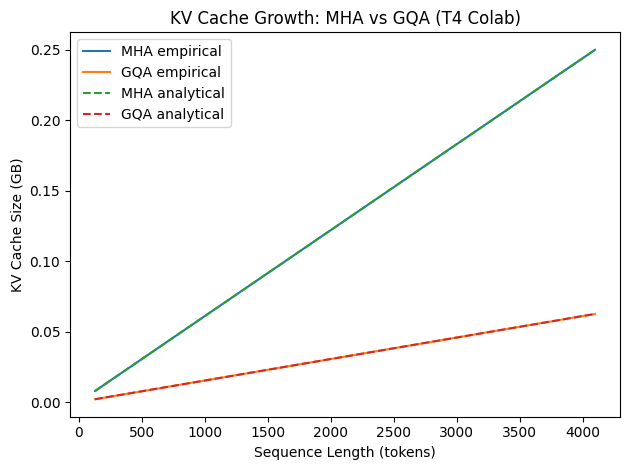


Final KV empirical:
  MHA: 0.250000 GB
  GQA: 0.062500 GB
  Reduction factor: 4.00x (expected ~4.00x)


In [ ]:
# Use sizes that are safe on a Colab T4.
# You can raise total_tokens to 8192 if it fits.
base = SimConfig(
    hidden_size=1024,
    num_layers=16,
    num_heads=16,
    batch_size=1,
    prompt_tokens=128,
    total_tokens=4096,
    measure_every=256,
    dtype=torch.float16,
)

cfg_mha = SimConfig(**{**base.__dict__, "num_kv_heads": base.num_heads})  # MHA
cfg_gqa = SimConfig(**{**base.__dict__, "num_kv_heads": 4})              # GQA example

print("Running MHA...")
res_mha = run_kv_growth(cfg_mha)

print("Running GQA...")
res_gqa = run_kv_growth(cfg_gqa)

def print_tail(name, cfg, res, k=6):
    print(f"\n=== {name} ===")
    print(f"layers={cfg.num_layers} heads={cfg.num_heads} kv_heads={cfg.num_kv_heads} hidden={cfg.hidden_size} dtype={cfg.dtype}")
    print("Last rows:")
    for i in range(max(0, len(res["seq_len"]) - k), len(res["seq_len"])):
        s = res["seq_len"][i]
        e = res["kv_gb_empirical"][i]
        a = res["kv_gb_analytical"][i]
        ms = res["step_time_ms"][i]
        ga = res["gpu_alloc_gb"][i]
        gr = res["gpu_reserved_gb"][i]
        print(f"  seq={s:6d}  KV_emp={e:.6f} GB  KV_ana={a:.6f} GB  step={ms:7.2f} ms  gpu_alloc={ga}  gpu_res={gr}")

print_tail("MHA", cfg_mha, res_mha)
print_tail("GQA", cfg_gqa, res_gqa)

# Plot KV growth
plt.figure()
plt.plot(res_mha["seq_len"], res_mha["kv_gb_empirical"], label="MHA empirical")
plt.plot(res_gqa["seq_len"], res_gqa["kv_gb_empirical"], label="GQA empirical")
plt.plot(res_mha["seq_len"], res_mha["kv_gb_analytical"], linestyle="--", label="MHA analytical")
plt.plot(res_gqa["seq_len"], res_gqa["kv_gb_analytical"], linestyle="--", label="GQA analytical")
plt.xlabel("Sequence Length (tokens)")
plt.ylabel("KV Cache Size (GB)")
plt.title("KV Cache Growth: MHA vs GQA (T4 Colab)")
plt.legend()
plt.tight_layout()
plt.show()

# Print reduction at final point
final_mha = res_mha["kv_gb_empirical"][-1]
final_gqa = res_gqa["kv_gb_empirical"][-1]
print("\nFinal KV empirical:")
print(f"  MHA: {final_mha:.6f} GB")
print(f"  GQA: {final_gqa:.6f} GB")
print(f"  Reduction factor: {final_mha / max(final_gqa, 1e-12):.2f}x (expected ~{cfg_mha.num_heads/cfg_gqa.num_kv_heads:.2f}x)")

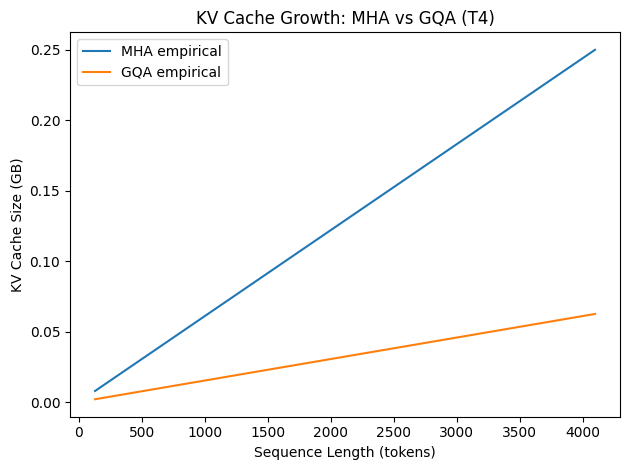

In [ ]:
plt.figure()
plt.plot(res_mha["seq_len"], res_mha["kv_gb_empirical"], label="MHA empirical")
plt.plot(res_gqa["seq_len"], res_gqa["kv_gb_empirical"], label="GQA empirical")
# plt.plot(res_mha["seq_len"], res_mha["kv_gb_analytical"], linestyle="--", label="MHA analytical")
# plt.plot(res_gqa["seq_len"], res_gqa["kv_gb_analytical"], linestyle="--", label="GQA analytical")
plt.xlabel("Sequence Length (tokens)")
plt.ylabel("KV Cache Size (GB)")
plt.title("KV Cache Growth: MHA vs GQA (T4)")
plt.legend()
plt.tight_layout()
plt.show()

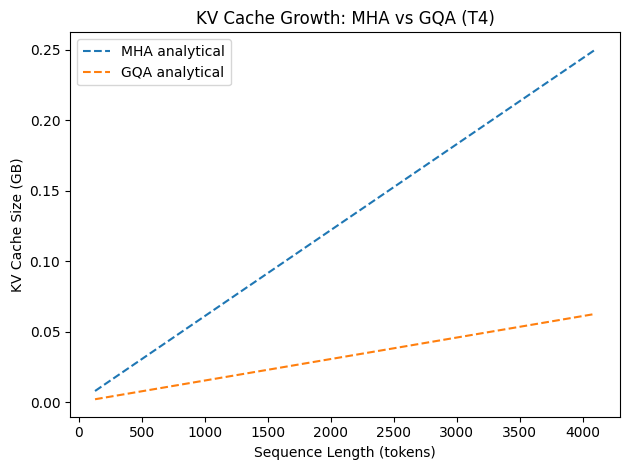

In [ ]:
plt.figure()
# plt.plot(res_mha["seq_len"], res_mha["kv_gb_empirical"], label="MHA empirical")
# plt.plot(res_gqa["seq_len"], res_gqa["kv_gb_empirical"], label="GQA empirical")
plt.plot(res_mha["seq_len"], res_mha["kv_gb_analytical"], linestyle="--", label="MHA analytical")
plt.plot(res_gqa["seq_len"], res_gqa["kv_gb_analytical"], linestyle="--", label="GQA analytical")
plt.xlabel("Sequence Length (tokens)")
plt.ylabel("KV Cache Size (GB)")
plt.title("KV Cache Growth: MHA vs GQA (T4)")
plt.legend()
plt.tight_layout()
plt.show()


Running kv_heads=16 ...

Running kv_heads=8 ...

Running kv_heads=4 ...

Running kv_heads=2 ...

Running kv_heads=1 ...


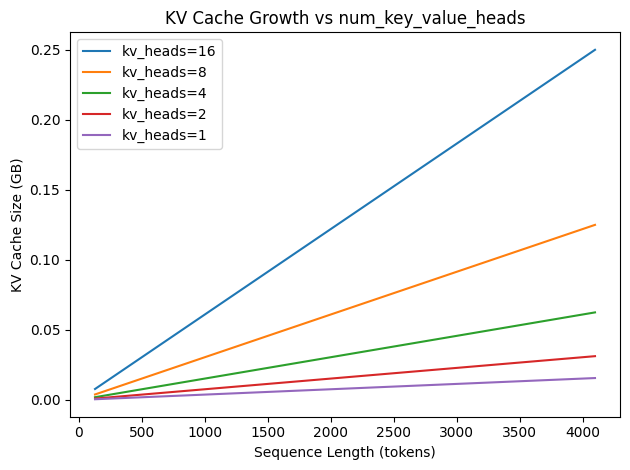


Final KV empirical at seq_len = 4096
  kv_heads=16: 0.250000 GB
  kv_heads= 8: 0.125000 GB
  kv_heads= 4: 0.062500 GB
  kv_heads= 2: 0.031250 GB
  kv_heads= 1: 0.015625 GB


In [ ]:
kv_heads_list = [16, 8, 4, 2, 1]  # MHA -> GQA -> MQA
sweep_results = {}

for kvh in kv_heads_list:
    cfg = SimConfig(**{**base.__dict__, "num_kv_heads": kvh})
    print(f"\nRunning kv_heads={kvh} ...")
    sweep_results[kvh] = run_kv_growth(cfg)

plt.figure()
for kvh in kv_heads_list:
    res = sweep_results[kvh]
    plt.plot(res["seq_len"], res["kv_gb_empirical"], label=f"kv_heads={kvh}")
plt.xlabel("Sequence Length (tokens)")
plt.ylabel("KV Cache Size (GB)")
plt.title("KV Cache Growth vs num_key_value_heads")
plt.legend()
plt.tight_layout()
plt.show()

# Show final KV per kv_heads
print("\nFinal KV empirical at seq_len =", base.total_tokens)
for kvh in kv_heads_list:
    res = sweep_results[kvh]
    print(f"  kv_heads={kvh:2d}: {res['kv_gb_empirical'][-1]:.6f} GB")

# 6. Above Experiments for Pre-Trained Model (Tiny Llama)

## Install + Imports

In [ ]:
!pip -q install transformers accelerate matplotlib sentencepiece

In [ ]:
import time
from dataclasses import dataclass
from typing import Dict, List, Optional

import torch
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))

torch: 2.10.0+cu128
cuda available: True
gpu: Tesla T4


## KV sizing helpers

In [ ]:
DTYPE_BYTES = {
    torch.float32: 4,
    torch.float16: 2,
    torch.bfloat16: 2,
    torch.int8: 1,
}

def bytes_to_gb(nbytes: int) -> float:
    return nbytes / (1024**3)

def gpu_mem_gb():
    if not torch.cuda.is_available():
        return None
    alloc = torch.cuda.memory_allocated() / (1024**3)
    reserv = torch.cuda.memory_reserved() / (1024**3)
    return alloc, reserv

def sizeof_past_key_values(past_key_values) -> int:
    """
    Robust empirical KV bytes for HF caches:
      - legacy tuple-of-(k,v) per layer
      - Cache objects with .to_legacy_cache()
      - tolerates None entries
    """
    if past_key_values is None:
        return 0
    if hasattr(past_key_values, "to_legacy_cache"):
        past_key_values = past_key_values.to_legacy_cache()

    total = 0
    for layer_kv in past_key_values:
        if layer_kv is None:
            continue
        if isinstance(layer_kv, (tuple, list)):
            for t in layer_kv:
                if t is None:
                    continue
                total += t.numel() * t.element_size()
        else:
            t = layer_kv
            if t is not None and hasattr(t, "numel"):
                total += t.numel() * t.element_size()
    return total

def analytical_kv_bytes(
    num_layers: int,
    batch_size: int,
    seq_len: int,
    num_kv_heads: int,
    head_dim: int,
    dtype: torch.dtype,
) -> int:
    bytes_per = DTYPE_BYTES.get(dtype, torch.tensor([], dtype=dtype).element_size())
    # 2 for K + V
    return 2 * num_layers * batch_size * seq_len * num_kv_heads * head_dim * bytes_per

## Load model + run KV growth

In [ ]:
@dataclass
class RunCfg:
    batch_size: int = 1
    total_tokens: int = 2048        # <= model max_position_embeddings for these models
    measure_every: int = 128
    prompt_text: str = "Summarize the following meeting:\n" + ("hello " * 200)

def load_model_and_tokenizer(model_id: str, dtype=torch.float16):
    tok = AutoTokenizer.from_pretrained(model_id, use_fast=True)

    # Some LLaMA-family tokenizers don't define pad_token by default.
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token

    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        torch_dtype=dtype,
        device_map="auto",
        attn_implementation="eager",  # stable cache format; not the fastest, but consistent for measurement
    ).eval()

    return tok, model

@torch.no_grad()
def run_kv_growth_pretrained(model, tokenizer, run_cfg: RunCfg) -> Dict[str, List]:
    cfg = model.config

    num_layers = getattr(cfg, "num_hidden_layers")
    num_heads = getattr(cfg, "num_attention_heads")
    num_kv_heads = getattr(cfg, "num_key_value_heads", num_heads)  # if absent -> equals heads (MHA)
    hidden_size = getattr(cfg, "hidden_size")
    head_dim = hidden_size // num_heads

    dtype = next(model.parameters()).dtype
    device = next(model.parameters()).device

    # tokenize prompt
    prompt = tokenizer(run_cfg.prompt_text, return_tensors="pt")
    input_ids = prompt["input_ids"].to(device)

    # ensure we don't exceed total_tokens during prefill
    if input_ids.shape[1] > run_cfg.total_tokens:
        input_ids = input_ids[:, : run_cfg.total_tokens]

    # prefill
    t0 = time.time()
    out = model(input_ids=input_ids, use_cache=True, return_dict=True)
    past = out.past_key_values
    prefill_ms = (time.time() - t0) * 1000
    seq_len = input_ids.shape[1]

    results = {
        "seq_len": [],
        "kv_gb_empirical": [],
        "kv_gb_analytical_actual": [],
        "kv_gb_analytical_mha": [],      # hypothetical MHA baseline
        "step_time_ms": [],
        "gpu_alloc_gb": [],
        "gpu_reserved_gb": [],
        "meta": {
            "num_layers": num_layers,
            "num_heads": num_heads,
            "num_kv_heads": num_kv_heads,
            "hidden_size": hidden_size,
            "head_dim": head_dim,
            "dtype": str(dtype),
            "max_pos": getattr(cfg, "max_position_embeddings", None),
            "model_type": getattr(cfg, "model_type", None),
        }
    }

    def record(cur_len: int, step_ms: float):
        emp = sizeof_past_key_values(past)
        ana_actual = analytical_kv_bytes(
            num_layers=num_layers,
            batch_size=run_cfg.batch_size,
            seq_len=cur_len,
            num_kv_heads=num_kv_heads,
            head_dim=head_dim,
            dtype=dtype,
        )
        ana_mha = analytical_kv_bytes(
            num_layers=num_layers,
            batch_size=run_cfg.batch_size,
            seq_len=cur_len,
            num_kv_heads=num_heads,  # MHA baseline
            head_dim=head_dim,
            dtype=dtype,
        )

        results["seq_len"].append(cur_len)
        results["kv_gb_empirical"].append(bytes_to_gb(emp))
        results["kv_gb_analytical_actual"].append(bytes_to_gb(ana_actual))
        results["kv_gb_analytical_mha"].append(bytes_to_gb(ana_mha))
        results["step_time_ms"].append(step_ms)

        gm = gpu_mem_gb()
        if gm is None:
            results["gpu_alloc_gb"].append(None)
            results["gpu_reserved_gb"].append(None)
        else:
            results["gpu_alloc_gb"].append(gm[0])
            results["gpu_reserved_gb"].append(gm[1])

    record(seq_len, prefill_ms)

    # token-by-token growth using cache
    vocab_size = getattr(cfg, "vocab_size")
    next_token = torch.randint(0, vocab_size, (run_cfg.batch_size, 1), device=device)

    while seq_len < run_cfg.total_tokens:
        t1 = time.time()
        out = model(input_ids=next_token, past_key_values=past, use_cache=True, return_dict=True)
        past = out.past_key_values
        dt_ms = (time.time() - t1) * 1000

        next_token = torch.randint(0, vocab_size, (run_cfg.batch_size, 1), device=device)
        seq_len += 1

        if (seq_len % run_cfg.measure_every) == 0 or seq_len == run_cfg.total_tokens:
            record(seq_len, dt_ms)

    return results

## Run MHA vs GQA and plot

Loading MHA model: openlm-research/open_llama_3b


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/593 [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/534k [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Running KV growth (GQA)...

=== MHA model ===
layers: 26 heads: 32 kv_heads: 32 hidden: 3200 head_dim: 100 dtype: torch.float16 max_pos: 2048
Final seq_len: 2048
Final KV empirical (GB): 0.634766
Final KV analytical actual (GB): 0.634766
Final KV analytical MHA baseline (GB): 0.634766

=== GQA model ===
layers: 22 heads: 32 kv_heads: 4 hidden: 2048 head_dim: 64 dtype: torch.float16 max_pos: 2048
Final seq_len: 2048
Final KV empirical (GB): 0.042969
Final KV analytical actual (GB): 0.042969
Final KV analytical MHA baseline (GB): 0.343750


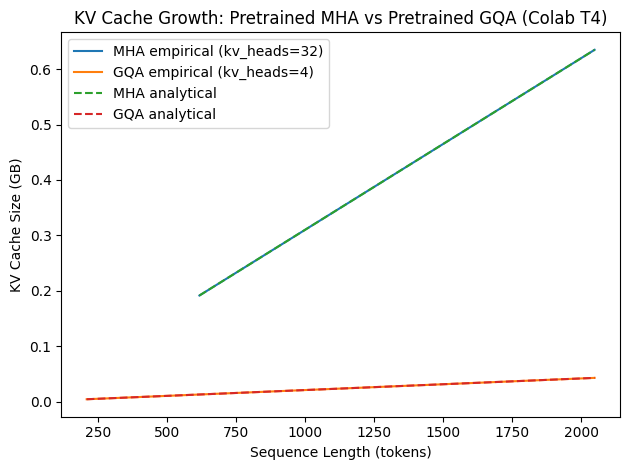


Final KV empirical:
  MHA: 0.634766 GB
  GQA: 0.042969 GB
  Reduction factor (MHA/GQA): 14.77x
  Expected ~ heads/kv_heads ratio: 8.00x (if head_dim/layers are similar)


In [ ]:
MHA_MODEL_ID = "openlm-research/open_llama_3b"
GQA_MODEL_ID = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

run_cfg = RunCfg(total_tokens=2048, measure_every=128)

# ---- Run MHA ----
print("Loading MHA model:", MHA_MODEL_ID)
tok_mha, model_mha = load_model_and_tokenizer(MHA_MODEL_ID, dtype=torch.float16)
print("Running KV growth (MHA)...")
res_mha = run_kv_growth_pretrained(model_mha, tok_mha, run_cfg)

# free GPU memory before loading second model
del model_mha
torch.cuda.empty_cache()

# ---- Run GQA ----
print("\nLoading GQA model:", GQA_MODEL_ID)
tok_gqa, model_gqa = load_model_and_tokenizer(GQA_MODEL_ID, dtype=torch.float16)
print("Running KV growth (GQA)...")
res_gqa = run_kv_growth_pretrained(model_gqa, tok_gqa, run_cfg)

del model_gqa
torch.cuda.empty_cache()

# ---- Print summaries ----
def describe(res, name):
    meta = res["meta"]
    print(f"\n=== {name} ===")
    print("layers:", meta["num_layers"], "heads:", meta["num_heads"], "kv_heads:", meta["num_kv_heads"],
          "hidden:", meta["hidden_size"], "head_dim:", meta["head_dim"], "dtype:", meta["dtype"], "max_pos:", meta["max_pos"])
    print("Final seq_len:", res["seq_len"][-1])
    print("Final KV empirical (GB):", f"{res['kv_gb_empirical'][-1]:.6f}")
    print("Final KV analytical actual (GB):", f"{res['kv_gb_analytical_actual'][-1]:.6f}")
    print("Final KV analytical MHA baseline (GB):", f"{res['kv_gb_analytical_mha'][-1]:.6f}")

describe(res_mha, "MHA model")
describe(res_gqa, "GQA model")

# ---- Plot KV cache growth ----
plt.figure()
plt.plot(res_mha["seq_len"], res_mha["kv_gb_empirical"], label=f"MHA empirical (kv_heads={res_mha['meta']['num_kv_heads']})")
plt.plot(res_gqa["seq_len"], res_gqa["kv_gb_empirical"], label=f"GQA empirical (kv_heads={res_gqa['meta']['num_kv_heads']})")

plt.plot(res_mha["seq_len"], res_mha["kv_gb_analytical_actual"], linestyle="--", label="MHA analytical")
plt.plot(res_gqa["seq_len"], res_gqa["kv_gb_analytical_actual"], linestyle="--", label="GQA analytical")

plt.xlabel("Sequence Length (tokens)")
plt.ylabel("KV Cache Size (GB)")
plt.title("KV Cache Growth: Pretrained MHA vs Pretrained GQA (Colab T4)")
plt.legend()
plt.tight_layout()
plt.show()

# ---- Report reduction factor at final length ----
final_mha = res_mha["kv_gb_empirical"][-1]
final_gqa = res_gqa["kv_gb_empirical"][-1]
print("\nFinal KV empirical:")
print("  MHA:", f"{final_mha:.6f}", "GB")
print("  GQA:", f"{final_gqa:.6f}", "GB")
print("  Reduction factor (MHA/GQA):", f"{final_mha / max(final_gqa, 1e-12):.2f}x")
print("  Expected ~ heads/kv_heads ratio:",
      f"{res_mha['meta']['num_heads'] / res_gqa['meta']['num_kv_heads']:.2f}x (if head_dim/layers are similar)")

# 7. Needle in a Haystack Test for Pretrained Models

In [ ]:
import math, random, time
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

import torch
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM


Loading model: MHA_open_llama_3b -> openlm-research/open_llama_3b


Loading weights:   0%|          | 0/237 [00:00<?, ?it/s]


--- cache_mode=fp16 ---


Token indices sequence length is longer than the specified maximum sequence length for this model (3072 > 2048). Running this sequence through the model will result in indexing errors


density=   low pos=0.10 seed=11 gold=B pred=A exact=False cacheGB=0.4572
density=   low pos=0.10 seed=22 gold=A pred=A exact=True cacheGB=0.9521
density=   low pos=0.10 seed=33 gold=A pred=A exact=True cacheGB=0.4649
density=   low pos=0.30 seed=11 gold=B pred=A exact=False cacheGB=0.4572
density=   low pos=0.30 seed=22 gold=A pred=A exact=True cacheGB=0.9521
density=   low pos=0.30 seed=33 gold=A pred=A exact=True cacheGB=0.4649
density=   low pos=0.50 seed=11 gold=B pred=A exact=False cacheGB=0.4572
density=   low pos=0.50 seed=22 gold=A pred=A exact=True cacheGB=0.9521
density=   low pos=0.50 seed=33 gold=A pred=A exact=True cacheGB=0.4649
density=   low pos=0.70 seed=11 gold=B pred=A exact=False cacheGB=0.4572
density=   low pos=0.70 seed=22 gold=A pred=A exact=True cacheGB=0.9521
density=   low pos=0.70 seed=33 gold=A pred=A exact=True cacheGB=0.4649
density=   low pos=0.90 seed=11 gold=B pred=A exact=False cacheGB=0.4572
density=   low pos=0.90 seed=22 gold=A pred=A exact=True ca

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


--- cache_mode=fp16 ---
density=   low pos=0.10 seed=11 gold=B pred=B exact=True cacheGB=0.0322
density=   low pos=0.10 seed=22 gold=A pred=B exact=False cacheGB=0.0318
density=   low pos=0.10 seed=33 gold=A pred=B exact=False cacheGB=0.0322
density=   low pos=0.30 seed=11 gold=B pred=B exact=True cacheGB=0.0322
density=   low pos=0.30 seed=22 gold=A pred=A exact=True cacheGB=0.0318
density=   low pos=0.30 seed=33 gold=A pred=B exact=False cacheGB=0.0322
density=   low pos=0.50 seed=11 gold=B pred=B exact=True cacheGB=0.0322
density=   low pos=0.50 seed=22 gold=A pred=A exact=True cacheGB=0.0318
density=   low pos=0.50 seed=33 gold=A pred=B exact=False cacheGB=0.0322
density=   low pos=0.70 seed=11 gold=B pred=B exact=True cacheGB=0.0322
density=   low pos=0.70 seed=22 gold=A pred=A exact=True cacheGB=0.0318
density=   low pos=0.70 seed=33 gold=A pred=A exact=True cacheGB=0.0322
density=   low pos=0.90 seed=11 gold=B pred=B exact=True cacheGB=0.0322
density=   low pos=0.90 seed=22 gol

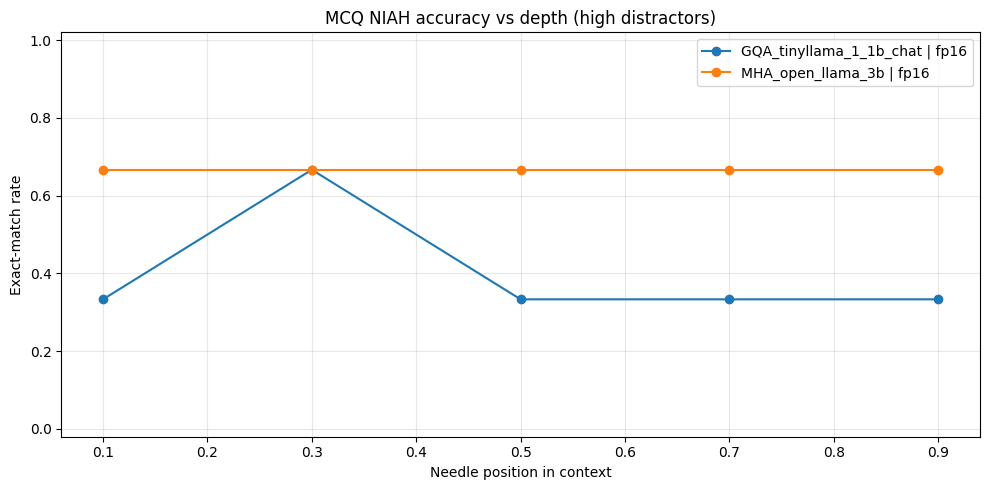

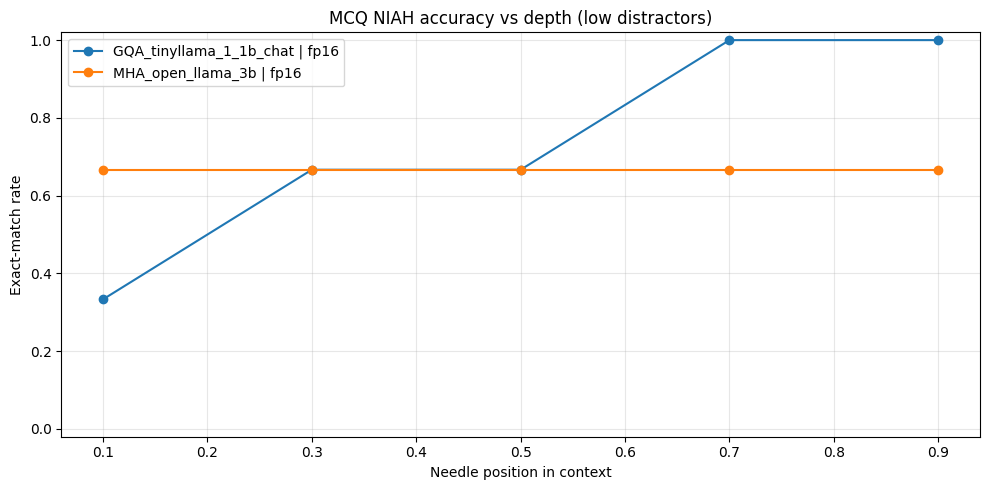

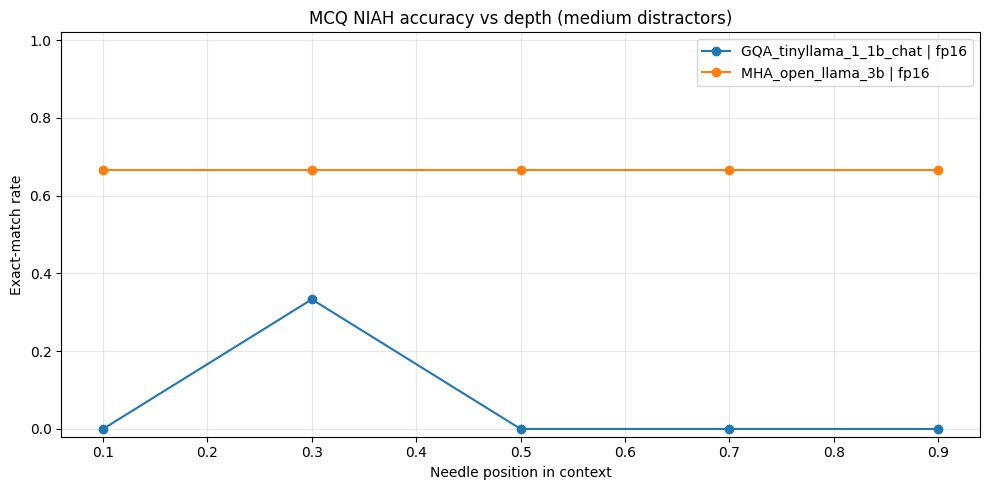

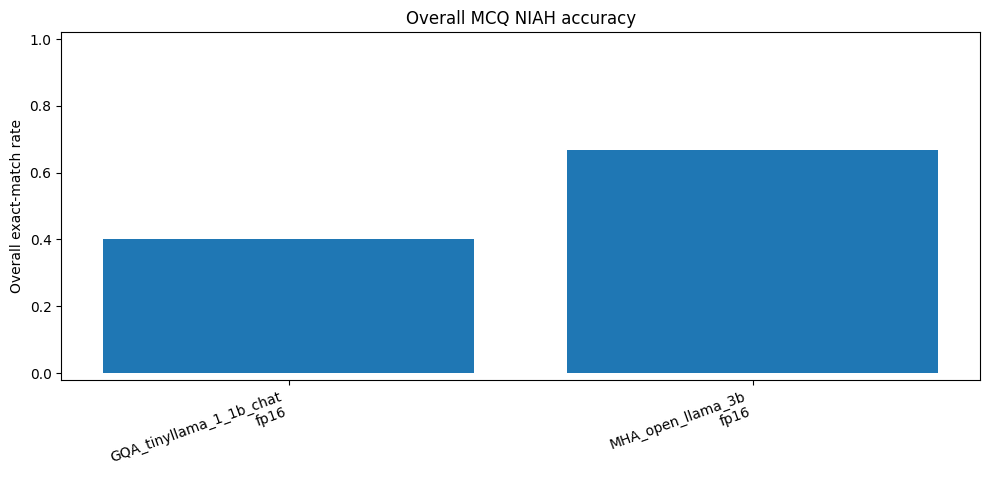

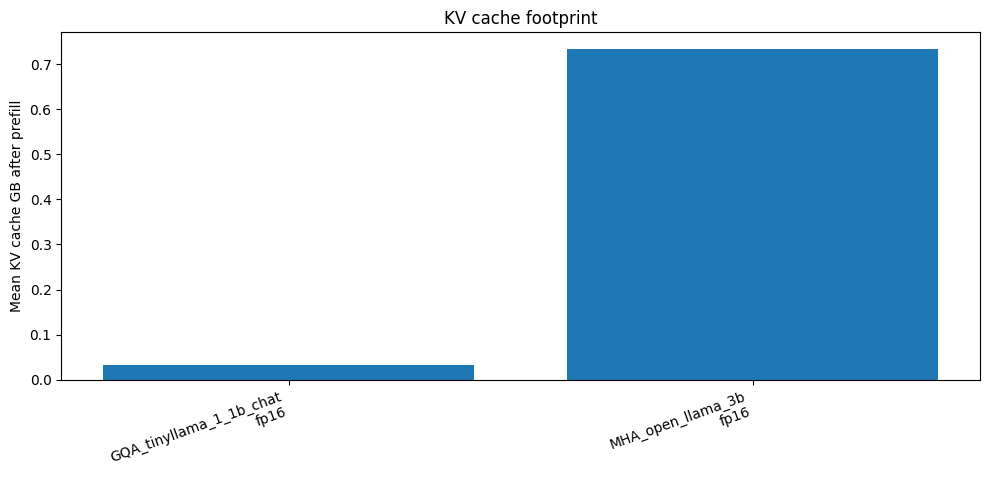

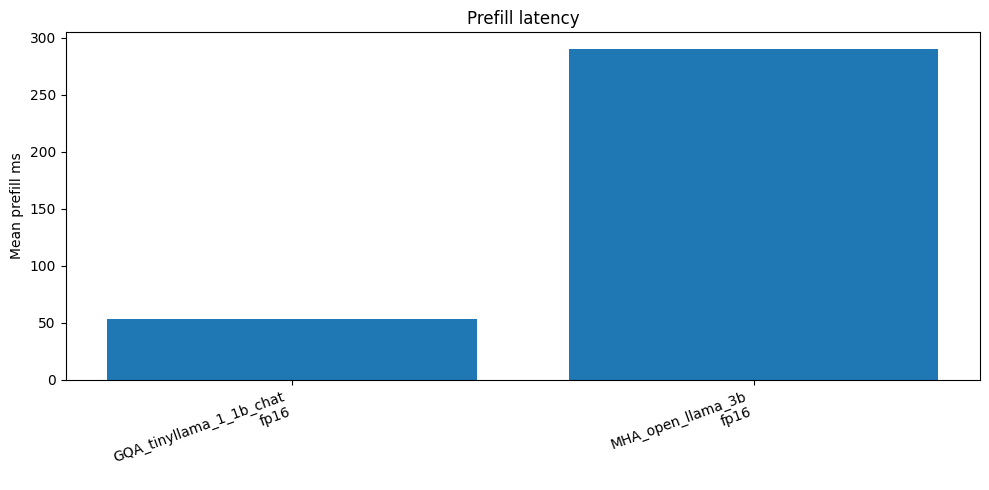

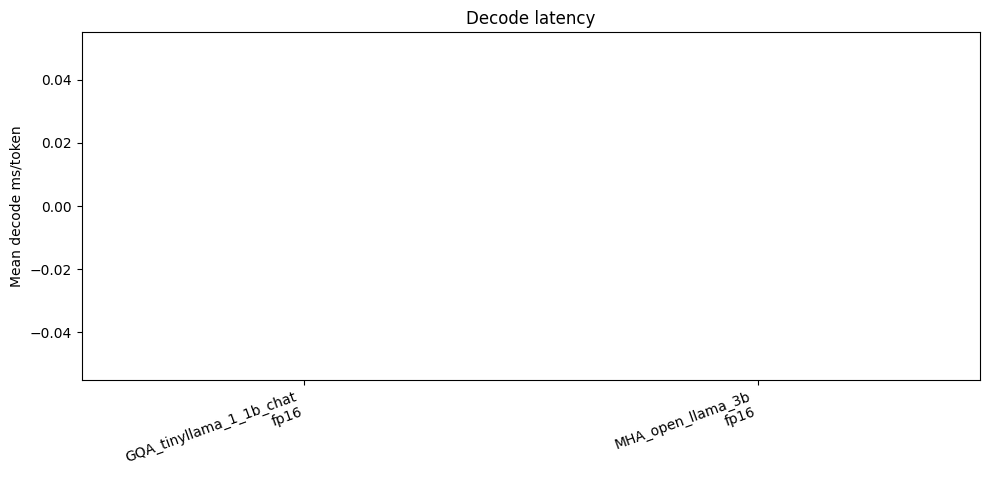

In [ ]:
# ============================================================
# END-TO-END MCQ NIAH BENCHMARK
# - Tests both MHA and GQA models
# - Uses official HF cache classes
# - Supports fp16 + quantized KV cache backends (if installed)
# - Uses multiple-choice needle retrieval instead of fragile free-form generation
# - Sweeps needle depth and distractor density
# - Includes summaries and visualizations
# ============================================================

import os
import gc
import re
import json
import time
import math
import random
import shutil
import tempfile
import statistics
from dataclasses import dataclass
from typing import Dict, List, Tuple, Any, Optional

import torch
import pandas as pd
import matplotlib.pyplot as plt

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    DynamicCache,
)

# Optional HF quantized-cache backends
try:
    from transformers import QuantizedCacheConfig, HQQQuantizedCache
    _HAS_HQQ = True
except Exception:
    _HAS_HQQ = False

try:
    from transformers import QuantizedCacheConfig, QuantoQuantizedCache
    _HAS_QUANTO = True
except Exception:
    _HAS_QUANTO = False


# ============================================================
# BASIC HELPERS
# ============================================================

def bytes_to_gb(nbytes: int) -> float:
    return nbytes / (1024 ** 3)

def gpu_mem_gb():
    if not torch.cuda.is_available():
        return None
    return (
        torch.cuda.memory_allocated() / (1024 ** 3),
        torch.cuda.memory_reserved() / (1024 ** 3),
    )

def recursive_tensor_bytes(obj, seen=None) -> int:
    """
    Recursively counts tensor storage reachable from an object.
    Useful for DynamicCache / QuantizedCache objects too.
    """
    if seen is None:
        seen = set()

    oid = id(obj)
    if oid in seen:
        return 0
    seen.add(oid)

    total = 0

    if torch.is_tensor(obj):
        return obj.numel() * obj.element_size()

    if isinstance(obj, dict):
        for v in obj.values():
            total += recursive_tensor_bytes(v, seen)
        return total

    if isinstance(obj, (list, tuple, set)):
        for v in obj:
            total += recursive_tensor_bytes(v, seen)
        return total

    if hasattr(obj, "__dict__"):
        for v in vars(obj).values():
            total += recursive_tensor_bytes(v, seen)

    return total


# ============================================================
# MODEL LOADING / CLEANUP
# ============================================================

def load_model_and_tokenizer(
    model_id: str,
    dtype=torch.float16,
    use_device_map_auto: bool = True,
    low_cpu_mem_usage: bool = True,
):
    """
    Loads model with an offload folder so larger models can still load under device_map='auto'.
    """
    tok = AutoTokenizer.from_pretrained(model_id, use_fast=True)
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token

    offload_dir = tempfile.mkdtemp(prefix="hf_offload_")

    load_kwargs = dict(
        torch_dtype=dtype,
        low_cpu_mem_usage=low_cpu_mem_usage,
        attn_implementation="eager",   # keep cache behavior predictable
        offload_folder=offload_dir,
    )

    if use_device_map_auto:
        load_kwargs["device_map"] = "auto"
    else:
        if torch.cuda.is_available():
            load_kwargs["device_map"] = {"": 0}
        else:
            load_kwargs["device_map"] = {"": "cpu"}

    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        **load_kwargs,
    ).eval()

    return tok, model, offload_dir

def cleanup_loaded_model(model=None, offload_dir=None):
    if model is not None:
        del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    if offload_dir and os.path.isdir(offload_dir):
        shutil.rmtree(offload_dir, ignore_errors=True)


# ============================================================
# CACHE FACTORY
# ============================================================

def make_cache(mode: str, model, device: torch.device):
    """
    Creates an HF cache object.

    Supported modes:
      - fp16        : regular DynamicCache
      - int8_hqq    : HQQ quantized KV cache, int8
      - int4_hqq    : HQQ quantized KV cache, int4
      - int4_quanto : Quanto quantized KV cache, int4
    """
    if mode == "fp16":
        return DynamicCache()

    if mode == "int8_hqq":
        if not _HAS_HQQ:
            raise RuntimeError("HQQ backend not available. Install with: pip install -U hqq")
        cfg = QuantizedCacheConfig(
            backend="hqq",
            nbits=8,
            axis_key=1,
            axis_value=1,
            q_group_size=64,
            residual_length=128,
            compute_dtype=next(model.parameters()).dtype,
            device=str(device),
        )
        return HQQQuantizedCache(cache_config=cfg)

    if mode == "int4_hqq":
        if not _HAS_HQQ:
            raise RuntimeError("HQQ backend not available. Install with: pip install -U hqq")
        cfg = QuantizedCacheConfig(
            backend="hqq",
            nbits=4,
            axis_key=1,
            axis_value=1,
            q_group_size=64,
            residual_length=128,
            compute_dtype=next(model.parameters()).dtype,
            device=str(device),
        )
        return HQQQuantizedCache(cache_config=cfg)

    if mode == "int4_quanto":
        if not _HAS_QUANTO:
            raise RuntimeError("Quanto backend not available. Install with: pip install -U optimum-quanto")
        cfg = QuantizedCacheConfig(
            backend="quanto",
            nbits=4,
            axis_key=0,
            axis_value=0,
            q_group_size=64,
            residual_length=128,
            compute_dtype=next(model.parameters()).dtype,
            device=str(device),
        )
        return QuantoQuantizedCache(cache_config=cfg)

    raise ValueError(f"Unknown cache mode: {mode}")


# ============================================================
# MCQ NEEDLE-IN-A-HAYSTACK PROMPT BUILDER
# ============================================================

_DISTRACTOR_KEYS = [
    "ORANGE-FALCON-17", "GREEN-DELTA-83", "AMBER-WHALE-29",
    "SILVER-ORBIT-56", "CRIMSON-LANTERN-91", "VIOLET-CEDAR-64",
    "BLACK-RIVER-38", "GOLDEN-NEXUS-72", "TEAL-PHOENIX-45",
    "WHITE-MATRIX-60", "COPPER-HORIZON-88", "MARBLE-QUEST-33",
]

_FILLER_TEMPLATES = [
    "Project memo {i}: The team reviewed milestone drift, customer escalations, staffing shortages, and delivery risks.",
    "Research note {i}: The experiment tracked latency, retrieval accuracy, perplexity drift, and calibration behavior over long context.",
    "Support summary {i}: Tickets covered account lockouts, onboarding confusion, retries, dashboard issues, and missing documentation.",
    "Finance update {i}: Invoice exceptions, approval chains, amended contracts, and quarterly budget revisions were reconciled.",
    "Audit page {i}: Reviewers checked access scope, file ownership, archival rules, and unresolved compliance concerns.",
    "Operations log {i}: Incoming shipments were checked, access badges rotated, warehouse counts reconciled, and discrepancy notes filed.",
]

def _rand_code(rng: random.Random) -> str:
    a = rng.choice([
        "BLUE", "RED", "GREEN", "SILVER", "GOLD", "BLACK",
        "WHITE", "VIOLET", "AMBER", "TEAL", "COPPER", "CRIMSON"
    ])
    b = rng.choice([
        "SPARROW", "FALCON", "PHOENIX", "RIVER", "CEDAR",
        "MATRIX", "HORIZON", "DELTA", "ORBIT", "LANTERN",
        "NEXUS", "QUEST"
    ])
    c = rng.randint(10, 99)
    return f"{a}-{b}-{c}"

def build_mcq_niah_prompt(
    tokenizer,
    target_total_tokens: int,
    needle_position: float,
    seed: int,
    num_choices: int = 4,
    distractor_density: str = "medium",   # low / medium / high
):
    """
    Builds a long-context archive with:
      - one true target key for one named entity
      - multiple distractor records
      - a multiple-choice question at the end

    Returns dict with:
      prompt_text, gold, gold_letter, choices, target_name, prompt_tokens, needle_position, seed
    """
    assert 0.0 < needle_position < 1.0
    assert num_choices >= 4

    rng = random.Random(seed)

    target_name = f"Agent-{rng.randint(1000, 9999)}"
    gold = _rand_code(rng)

    pool = list(set(_DISTRACTOR_KEYS + [_rand_code(rng) for _ in range(50)]))
    pool = [x for x in pool if x != gold]
    rng.shuffle(pool)

    choices = [gold] + pool[: num_choices - 1]
    rng.shuffle(choices)

    letters = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"
    choice_map = {letters[i]: choices[i] for i in range(num_choices)}
    gold_letter = [k for k, v in choice_map.items() if v == gold][0]

    prefix = (
        "You are reading a long mixed archive of operational notes, audit entries, and assignment records. "
        "Only one record contains the correct access key for the asked entity. "
        "Many other records are distractors.\n\n"
    )

    target_record = (
        f"Confidential assignment record: entity={target_name}; "
        f"department=field-ops; access_key={gold}; "
        f"status=active; verification=passed.\n"
    )

    distractor_records = []
    density_to_n = {"low": 8, "medium": 18, "high": 32}
    n_distractors = density_to_n.get(distractor_density, 18)

    for _ in range(n_distractors):
        distractor_records.append(
            f"Confidential assignment record: entity=Agent-{rng.randint(1000, 9999)}; "
            f"department={rng.choice(['field-ops', 'lab', 'finance', 'support'])}; "
            f"access_key={pool.pop()}; "
            f"status={rng.choice(['active', 'pending', 'archived'])}; "
            f"verification={rng.choice(['passed', 'manual-review', 'retry'])}.\n"
        )

    def token_len(text: str) -> int:
        return int(tokenizer(text, return_tensors="pt")["input_ids"].shape[1])

    # Leave space for the final question/options.
    body_budget = max(256, target_total_tokens - 180)
    target_insert_tokens = int(body_budget * needle_position)

    cur = prefix
    cur_tokens = token_len(cur)
    inserted = False
    i = 0

    while True:
        block_lines = []
        for _ in range(rng.randint(2, 5)):
            block_lines.append(_FILLER_TEMPLATES[i % len(_FILLER_TEMPLATES)].format(i=i))
            i += 1

        if distractor_records and rng.random() < 0.60:
            block_lines.append(distractor_records.pop())

        block = "\n".join(block_lines) + "\n"
        block_tokens = token_len(block)

        if (not inserted) and (cur_tokens + block_tokens >= target_insert_tokens):
            cur += target_record
            cur_tokens = token_len(cur)
            inserted = True

        cur += block
        cur_tokens = token_len(cur)

        if cur_tokens >= body_budget:
            break

    if not inserted:
        cur += target_record

    options_text = "\n".join([f"{k}. {v}" for k, v in choice_map.items()])

    question = (
        f"\n\nQuestion: Which option is the exact access key assigned to {target_name}?\n"
        f"{options_text}\n"
        "Reply with only the option letter.\n"
        "Answer:"
    )

    prompt_text = cur + question

    if hasattr(tokenizer, "apply_chat_template") and tokenizer.chat_template is not None:
        messages = [{"role": "user", "content": prompt_text}]
        prompt_text = tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True,
        )

    ids = tokenizer(prompt_text, return_tensors="pt")["input_ids"]
    if ids.shape[1] > target_total_tokens:
        ids = ids[:, -target_total_tokens:]
        prompt_text = tokenizer.decode(ids[0], skip_special_tokens=False)

    prompt_tokens = int(tokenizer(prompt_text, return_tensors="pt")["input_ids"].shape[1])

    return {
        "prompt_text": prompt_text,
        "gold": gold,
        "gold_letter": gold_letter,
        "choices": choice_map,
        "target_name": target_name,
        "prompt_tokens": prompt_tokens,
        "needle_position": needle_position,
        "seed": seed,
        "distractor_density": distractor_density,
    }


# ============================================================
# MCQ SCORING
# ============================================================

def extract_choice_letter(text: str, valid_letters=None):
    if valid_letters is None:
        valid_letters = list("ABCDEFGHIJKLMNOPQRSTUVWXYZ")

    s = text.strip().upper()

    if s in valid_letters:
        return s

    m = re.search(r"\b([A-Z])\b", s)
    if m and m.group(1) in valid_letters:
        return m.group(1)

    m = re.search(r"(?:ANSWER\s*[:\-]?\s*)?[\(\[]?([A-Z])[\)\].:]?", s)
    if m and m.group(1) in valid_letters:
        return m.group(1)

    return None

def score_mcq_answer(pred_text: str, gold_letter: str):
    pred_letter = extract_choice_letter(pred_text)
    return {
        "pred_letter": pred_letter,
        "exact_match": pred_letter == gold_letter,
    }


# ============================================================
# INFERENCE MODES
# ============================================================

@torch.no_grad()
def run_one_generation(
    model,
    tokenizer,
    prompt_text: str,
    cache_mode: str,
    max_new_tokens: int = 4,
):
    """
    Deterministic short generation. Better than free-form long answers,
    but still less stable than direct logit scoring.
    """
    device = next(model.parameters()).device
    inputs = tokenizer(prompt_text, return_tensors="pt")
    input_ids = inputs["input_ids"].to(device)

    cache = make_cache(cache_mode, model, device)

    t0 = time.time()
    out = model(
        input_ids=input_ids,
        past_key_values=cache,
        use_cache=True,
        return_dict=True,
    )
    prefill_ms = (time.time() - t0) * 1000.0

    past = out.past_key_values
    next_token = torch.argmax(out.logits[:, -1, :], dim=-1, keepdim=True)

    cache_bytes = recursive_tensor_bytes(past)

    step_times = []
    generated_ids = []

    for _ in range(max_new_tokens):
        t1 = time.time()
        out = model(
            input_ids=next_token,
            past_key_values=past,
            use_cache=True,
            return_dict=True,
        )
        step_times.append((time.time() - t1) * 1000.0)
        past = out.past_key_values
        next_token = torch.argmax(out.logits[:, -1, :], dim=-1, keepdim=True)
        generated_ids.append(next_token.item())

    generated_text = tokenizer.decode(generated_ids, skip_special_tokens=True).strip()

    gm = gpu_mem_gb()

    return {
        "generated_text": generated_text,
        "prefill_ms": prefill_ms,
        "avg_decode_ms": float(sum(step_times) / max(1, len(step_times))),
        "cache_gb_after_prefill": bytes_to_gb(cache_bytes),
        "gpu_alloc_gb": None if gm is None else gm[0],
        "gpu_reserved_gb": None if gm is None else gm[1],
    }

@torch.no_grad()
def run_one_mcq_logit_eval(
    model,
    tokenizer,
    prompt_text: str,
    cache_mode: str,
    valid_letters=("A", "B", "C", "D"),
):
    """
    Preferred mode: evaluate which option letter has the highest next-token logit
    immediately after the prompt. This removes decoding noise.
    """
    device = next(model.parameters()).device
    inputs = tokenizer(prompt_text, return_tensors="pt")
    input_ids = inputs["input_ids"].to(device)

    cache = make_cache(cache_mode, model, device)

    t0 = time.time()
    out = model(
        input_ids=input_ids,
        past_key_values=cache,
        use_cache=True,
        return_dict=True,
    )
    prefill_ms = (time.time() - t0) * 1000.0

    past = out.past_key_values
    logits = out.logits[:, -1, :]

    scores = {}
    for letter in valid_letters:
        ids = tokenizer.encode(letter, add_special_tokens=False)
        if len(ids) == 1:
            tid = ids[0]
            scores[letter] = float(logits[0, tid].item())

    pred_letter = max(scores, key=scores.get) if scores else None

    cache_bytes = recursive_tensor_bytes(past)
    gm = gpu_mem_gb()

    return {
        "pred_letter": pred_letter,
        "scores": scores,
        "prefill_ms": prefill_ms,
        "avg_decode_ms": 0.0,
        "cache_gb_after_prefill": bytes_to_gb(cache_bytes),
        "gpu_alloc_gb": None if gm is None else gm[0],
        "gpu_reserved_gb": None if gm is None else gm[1],
    }


# ============================================================
# BENCHMARK CONFIG
# ============================================================

@dataclass
class NIAHBenchCfg:
    models: Dict[str, str]
    cache_modes: List[str]
    target_total_tokens: int = 1536
    max_new_tokens: int = 4
    positions: Tuple[float, ...] = (0.10, 0.30, 0.50, 0.70, 0.90)
    seeds: Tuple[int, ...] = (11, 22, 33)
    distractor_densities: Tuple[str, ...] = ("low", "medium", "high")
    use_logit_eval: bool = True


# ============================================================
# MAIN BENCHMARK RUNNER
# ============================================================

def run_niah_benchmark(cfg: NIAHBenchCfg) -> pd.DataFrame:
    rows = []

    for model_name, model_id in cfg.models.items():
        print(f"\n==============================")
        print(f"Loading model: {model_name} -> {model_id}")
        print(f"==============================")

        tok, model, offload_dir = load_model_and_tokenizer(
            model_id,
            dtype=torch.float16,
            use_device_map_auto=True,
        )

        try:
            max_ctx = getattr(model.config, "max_position_embeddings", cfg.target_total_tokens)
            safe_target_total_tokens = min(cfg.target_total_tokens, max_ctx - cfg.max_new_tokens - 8)

            cache_modes = []
            for m in cfg.cache_modes:
                if m.startswith("int8_hqq") and not _HAS_HQQ:
                    print("Skipping int8_hqq (hqq not installed)")
                    continue
                if m.startswith("int4_hqq") and not _HAS_HQQ:
                    print("Skipping int4_hqq (hqq not installed)")
                    continue
                if m.startswith("int4_quanto") and not _HAS_QUANTO:
                    print("Skipping int4_quanto (optimum-quanto not installed)")
                    continue
                cache_modes.append(m)

            for cache_mode in cache_modes:
                print(f"\n--- cache_mode={cache_mode} ---")

                for density in cfg.distractor_densities:
                    for pos in cfg.positions:
                        for seed in cfg.seeds:
                            ex = build_mcq_niah_prompt(
                                tokenizer=tok,
                                target_total_tokens=safe_target_total_tokens,
                                needle_position=pos,
                                seed=seed,
                                num_choices=4,
                                distractor_density=density,
                            )

                            if cfg.use_logit_eval:
                                out = run_one_mcq_logit_eval(
                                    model=model,
                                    tokenizer=tok,
                                    prompt_text=ex["prompt_text"],
                                    cache_mode=cache_mode,
                                    valid_letters=tuple(ex["choices"].keys()),
                                )
                                pred_letter = out["pred_letter"]
                                exact_match = pred_letter == ex["gold_letter"]
                                generated_text = ""
                            else:
                                out = run_one_generation(
                                    model=model,
                                    tokenizer=tok,
                                    prompt_text=ex["prompt_text"],
                                    cache_mode=cache_mode,
                                    max_new_tokens=cfg.max_new_tokens,
                                )
                                sc = score_mcq_answer(out["generated_text"], ex["gold_letter"])
                                pred_letter = sc["pred_letter"]
                                exact_match = sc["exact_match"]
                                generated_text = out["generated_text"]

                            row = {
                                "model_name": model_name,
                                "model_id": model_id,
                                "cache_mode": cache_mode,
                                "needle_position": pos,
                                "distractor_density": density,
                                "seed": seed,
                                "prompt_tokens": ex["prompt_tokens"],
                                "gold": ex["gold"],
                                "gold_letter": ex["gold_letter"],
                                "target_name": ex["target_name"],
                                "choices": json.dumps(ex["choices"]),
                                "generated_text": generated_text,
                                "pred_letter": pred_letter,
                                "exact_match": exact_match,
                                "prefill_ms": out["prefill_ms"],
                                "avg_decode_ms": out["avg_decode_ms"],
                                "cache_gb_after_prefill": out["cache_gb_after_prefill"],
                                "gpu_alloc_gb": out["gpu_alloc_gb"],
                                "gpu_reserved_gb": out["gpu_reserved_gb"],
                            }
                            rows.append(row)

                            print(
                                f"density={density:>6} pos={pos:.2f} seed={seed} "
                                f"gold={ex['gold_letter']} pred={pred_letter} "
                                f"exact={exact_match} "
                                f"cacheGB={row['cache_gb_after_prefill']:.4f}"
                            )
        finally:
            cleanup_loaded_model(model, offload_dir)

    return pd.DataFrame(rows)


# ============================================================
# SUMMARIES
# ============================================================

def summarize_niah_results(df: pd.DataFrame) -> pd.DataFrame:
    return (
        df.groupby(
            ["model_name", "cache_mode", "distractor_density", "needle_position"],
            as_index=False,
        )
        .agg(
            exact_match_rate=("exact_match", "mean"),
            mean_prefill_ms=("prefill_ms", "mean"),
            mean_decode_ms=("avg_decode_ms", "mean"),
            mean_cache_gb=("cache_gb_after_prefill", "mean"),
            n=("exact_match", "count"),
        )
    )

def summarize_overall_accuracy(df: pd.DataFrame) -> pd.DataFrame:
    return (
        df.groupby(["model_name", "cache_mode"], as_index=False)
        .agg(
            exact_match_rate=("exact_match", "mean"),
            mean_prefill_ms=("prefill_ms", "mean"),
            mean_decode_ms=("avg_decode_ms", "mean"),
            mean_cache_gb=("cache_gb_after_prefill", "mean"),
            n=("exact_match", "count"),
        )
    )


# ============================================================
# VISUALIZATIONS
# ============================================================

def plot_niah_results(df: pd.DataFrame):
    summary = summarize_niah_results(df)

    # 1) Accuracy vs depth for each distractor level
    for density in sorted(summary["distractor_density"].unique()):
        plt.figure(figsize=(10, 5))
        sub = summary[summary["distractor_density"] == density]

        for (model_name, cache_mode), g in sub.groupby(["model_name", "cache_mode"]):
            g = g.sort_values("needle_position")
            plt.plot(
                g["needle_position"],
                g["exact_match_rate"],
                marker="o",
                label=f"{model_name} | {cache_mode}",
            )

        plt.xlabel("Needle position in context")
        plt.ylabel("Exact-match rate")
        plt.title(f"MCQ NIAH accuracy vs depth ({density} distractors)")
        plt.ylim(-0.02, 1.02)
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

    # 2) Overall accuracy by model/cache mode
    overall = summarize_overall_accuracy(df)
    plt.figure(figsize=(10, 5))
    labels = [f"{m}\n{c}" for m, c in zip(overall["model_name"], overall["cache_mode"])]
    plt.bar(range(len(overall)), overall["exact_match_rate"])
    plt.xticks(range(len(overall)), labels, rotation=20, ha="right")
    plt.ylabel("Overall exact-match rate")
    plt.title("Overall MCQ NIAH accuracy")
    plt.ylim(-0.02, 1.02)
    plt.tight_layout()
    plt.show()

    # 3) Mean KV cache size
    plt.figure(figsize=(10, 5))
    labels2 = [f"{m}\n{c}" for m, c in zip(overall["model_name"], overall["cache_mode"])]
    plt.bar(range(len(overall)), overall["mean_cache_gb"])
    plt.xticks(range(len(overall)), labels2, rotation=20, ha="right")
    plt.ylabel("Mean KV cache GB after prefill")
    plt.title("KV cache footprint")
    plt.tight_layout()
    plt.show()

    # 4) Prefill latency
    plt.figure(figsize=(10, 5))
    plt.bar(range(len(overall)), overall["mean_prefill_ms"])
    plt.xticks(range(len(overall)), labels2, rotation=20, ha="right")
    plt.ylabel("Mean prefill ms")
    plt.title("Prefill latency")
    plt.tight_layout()
    plt.show()

    # 5) Decode latency
    plt.figure(figsize=(10, 5))
    plt.bar(range(len(overall)), overall["mean_decode_ms"])
    plt.xticks(range(len(overall)), labels2, rotation=20, ha="right")
    plt.ylabel("Mean decode ms/token")
    plt.title("Decode latency")
    plt.tight_layout()
    plt.show()


# ============================================================
# OPTIONAL: QUICK SANITY SAMPLE
# ============================================================

def preview_example_prompt(model_id: str, target_total_tokens: int = 1024):
    tok, model, offload_dir = load_model_and_tokenizer(model_id, dtype=torch.float16)
    try:
        max_ctx = getattr(model.config, "max_position_embeddings", target_total_tokens)
        safe_target_total_tokens = min(target_total_tokens, max_ctx - 16)

        ex = build_mcq_niah_prompt(
            tokenizer=tok,
            target_total_tokens=safe_target_total_tokens,
            needle_position=0.5,
            seed=11,
            num_choices=4,
            distractor_density="medium",
        )
        print("Prompt tokens:", ex["prompt_tokens"])
        print("Target name :", ex["target_name"])
        print("Gold key    :", ex["gold"])
        print("Gold letter :", ex["gold_letter"])
        print("Choices     :", ex["choices"])
        print("\n--- Prompt preview ---\n")
        print(ex["prompt_text"][:2500])
    finally:
        cleanup_loaded_model(model, offload_dir)


# ============================================================
# RUN CONFIG
# ============================================================

# If open_llama_3b is too large for your environment, replace it with:
#   "EleutherAI/pythia-1b"
# which is MHA and often easier to run.
MODEL_SPECS = {
    "MHA_open_llama_3b": "openlm-research/open_llama_3b",
    "GQA_tinyllama_1_1b_chat": "TinyLlama/TinyLlama-1.1B-Chat-v1.0",
}

bench_cfg = NIAHBenchCfg(
    models=MODEL_SPECS,
    cache_modes=[
        "fp16",
        # Uncomment after installation:
        #"int8_hqq",
        # "int4_hqq",
        # "int4_quanto",
    ],
    target_total_tokens=1536,
    max_new_tokens=4,
    positions=(0.10, 0.30, 0.50, 0.70, 0.90),
    seeds=(11, 22, 33),
    distractor_densities=("low", "medium", "high"),
    use_logit_eval=True,   # recommended
)

# ============================================================
# EXECUTE
# ============================================================

# Optional preview:
# preview_example_prompt("TinyLlama/TinyLlama-1.1B-Chat-v1.0", target_total_tokens=1024)

niah_df = run_niah_benchmark(bench_cfg)
niah_summary = summarize_niah_results(niah_df)
niah_overall = summarize_overall_accuracy(niah_df)

print("\n=== Summary by depth and distractor density ===")
print(niah_summary)

print("\n=== Overall summary ===")
print(niah_overall)

plot_niah_results(niah_df)